# Help Desk Ticket Analysis - Exploratory Data Analysis (EDA)

This notebook explores help desk ticket data to identify operational trends, SLA performance, and factors influencing ticket resolution times.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/cleaned/help_desk_cleaned.csv")

## 1. Data Overview

In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141707 entries, 0 to 141706
Data columns (total 30 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   number                   141707 non-null  object
 1   incident_state           141707 non-null  object
 2   active                   141707 non-null  bool  
 3   reassignment_count       141707 non-null  int64 
 4   reopen_count             141707 non-null  int64 
 5   sys_mod_count            141707 non-null  int64 
 6   made_sla                 141707 non-null  bool  
 7   caller_id                141678 non-null  object
 8   opened_by                136872 non-null  object
 9   opened_at                141707 non-null  object
 10  sys_updated_by           141707 non-null  object
 11  sys_updated_at           141707 non-null  object
 12  contact_type             141707 non-null  object
 13  location                 141631 non-null  object
 14  category            

,reassignment_count,reopen_count,sys_mod_count
count,141707.000000,141707.000000,141707.000000
mean,1.104215,0.021918,5.080758
std,1.734699,0.207306,7.680592
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,1.000000
50%,1.000000,0.000000,3.000000
75%,1.000000,0.000000,6.000000
max,27.000000,8.000000,129.000000


In [4]:
df.isnull().sum()

number                         0
incident_state                 0
active                         0
reassignment_count             0
reopen_count                   0
sys_mod_count                  0
made_sla                       0
caller_id                     29
opened_by                   4835
opened_at                      0
sys_updated_by                 0
sys_updated_at                 0
contact_type                   0
location                      76
category                      78
subcategory                  111
symptom                    32959
impact                         0
urgency                        0
priority                       0
assignment_group           14213
assigned_to                27496
knowledge                      0
u_priority_confirmation        0
notify                         0
closed_code                  714
resolved_by                  226
resolved_at                 3141
closed_at                  85391
isParent                       0
dtype: int

## 2. Data Preparation

In [5]:
datetime_cols = [
    "opened_at",
    "resolved_at",
    "closed_at",
    "sys_updated_at"
]

for col in datetime_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

C:\Users\saura\AppData\Local\Temp\ipykernel_14948\1236737711.py:9: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col], errors="coerce")


In [6]:
df["resolution_hours"] = (
    df["resolved_at"] - df["opened_at"]
).dt.total_seconds() / 3600

In [7]:
print(df["resolution_hours"].describe())
print((df["resolution_hours"] < 0).sum())

count    138566.000000
mean        269.575059
std         650.869539
min           0.000000
25%           4.066667
50%          73.516667
75%         262.183333
max        8070.166667
Name: resolution_hours, dtype: float64
0


## 3. Distribution Analysis

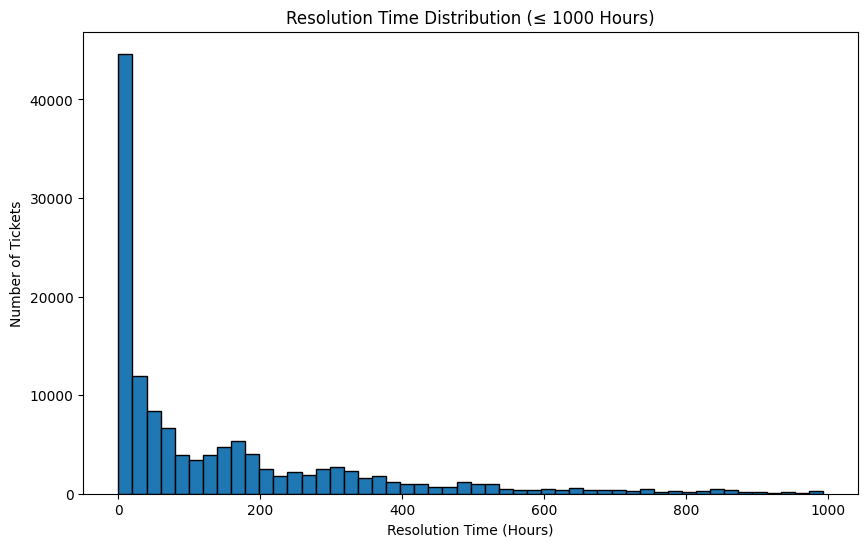

In [8]:
plt.figure(figsize=(10, 6))

plt.hist(
    df.loc[df["resolution_hours"] <= 1000, "resolution_hours"].dropna(),
    bins=50,
    edgecolor="black"
)

plt.title("Resolution Time Distribution (≤ 1000 Hours)")
plt.xlabel("Resolution Time (Hours)")
plt.ylabel("Number of Tickets")

plt.show()

Most tickets are resolved within the lower time ranges, while the distribution remains heavily right-skewed, indicating a small proportion of tickets require significantly longer resolution times.

## 4. Business Relationship Analysis

<Figure size 800x600 with 0 Axes>

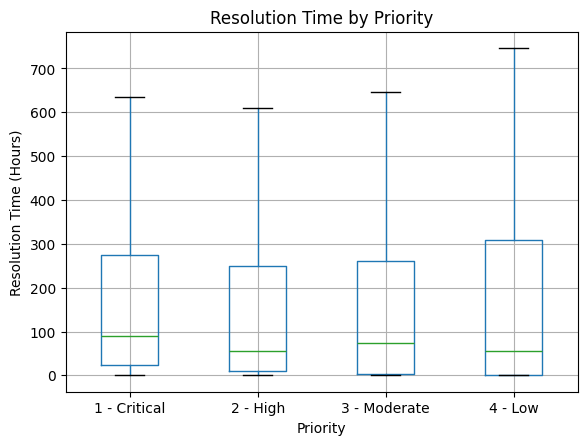

In [9]:
plt.figure(figsize=(8, 6))

df.boxplot(
    column="resolution_hours",
    by="priority",
    showfliers=False  # Hides extreme outliers for better readability
)

plt.title("Resolution Time by Priority")
plt.suptitle("")  # Removes automatic pandas subtitle
plt.xlabel("Priority")
plt.ylabel("Resolution Time (Hours)")

plt.show()

Resolution times vary across priority levels, with lower-priority tickets generally exhibiting greater variability and longer completion windows than higher-priority incidents.

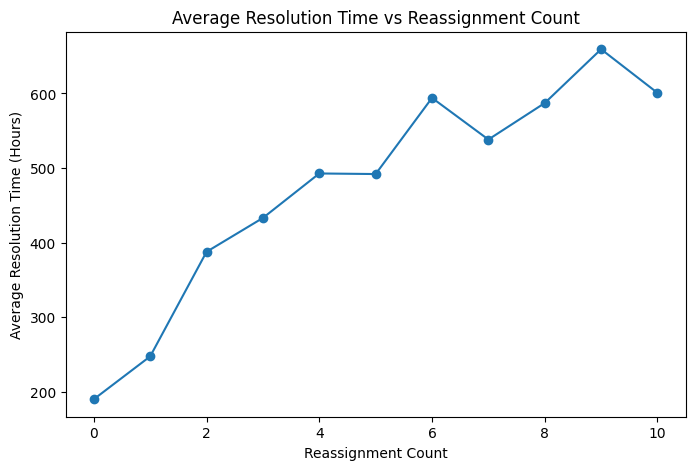

In [10]:
avg_time = (
    df[df["reassignment_count"] <= 10]
    .groupby("reassignment_count")["resolution_hours"]
    .mean()
)

plt.figure(figsize=(8,5))
plt.plot(avg_time.index, avg_time.values, marker="o")

plt.title("Average Resolution Time vs Reassignment Count")
plt.xlabel("Reassignment Count")
plt.ylabel("Average Resolution Time (Hours)")

plt.show()

Average resolution time increases as reassignment count grows, suggesting that repeated ticket handoffs contribute to slower issue resolution.

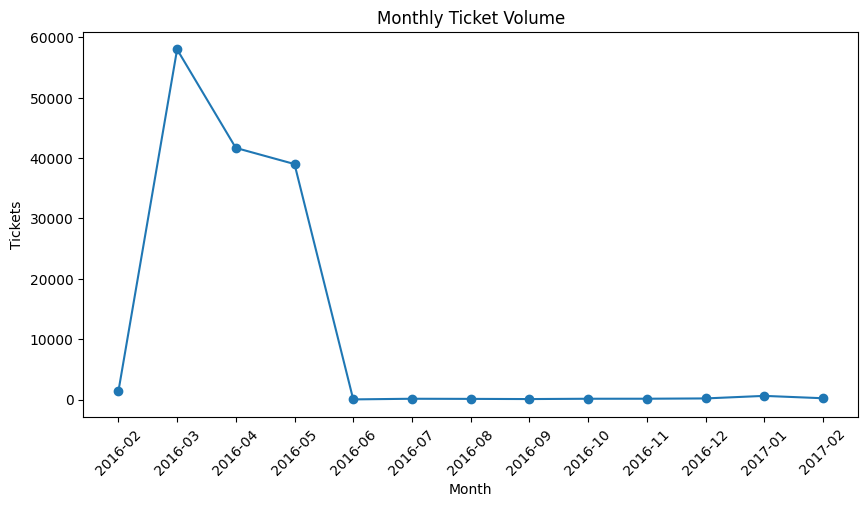

In [11]:
monthly = (
    df.groupby(df["opened_at"].dt.to_period("M"))
      .size()
)

monthly.index = monthly.index.astype(str)

plt.figure(figsize=(10,5))
plt.plot(monthly.index, monthly.values, marker="o")
plt.xticks(rotation=45)
plt.title("Monthly Ticket Volume")
plt.xlabel("Month")
plt.ylabel("Tickets")
plt.show()

Ticket volumes peaked during the early months of the dataset before declining sharply, indicating substantial variation in workload over time.

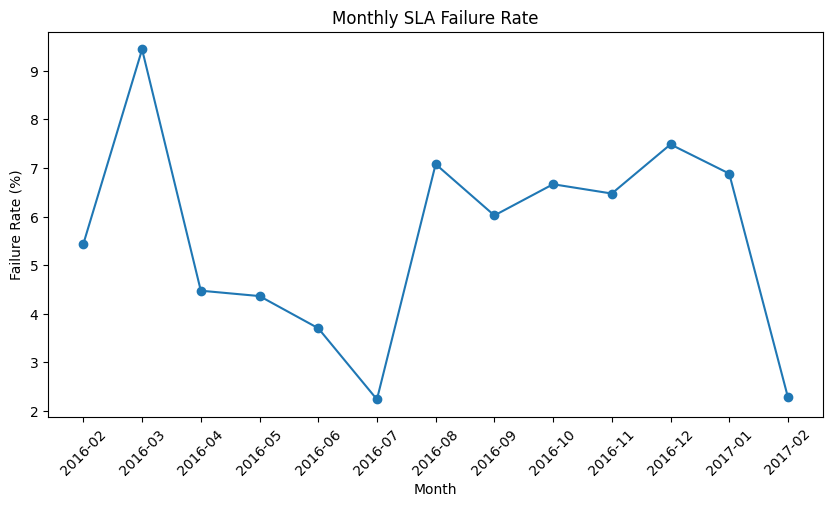

In [12]:
monthly_sla = (
    df.groupby(df["opened_at"].dt.to_period("M"))["made_sla"]
      .apply(lambda x: (x == False).mean() * 100)
)

monthly_sla.index = monthly_sla.index.astype(str)

plt.figure(figsize=(10,5))
plt.plot(monthly_sla.index, monthly_sla.values, marker="o")
plt.xticks(rotation=45)
plt.title("Monthly SLA Failure Rate")
plt.xlabel("Month")
plt.ylabel("Failure Rate (%)")
plt.show()

SLA failure rates fluctuate across months, highlighting periods where operational performance may have deteriorated and warrant further investigation.

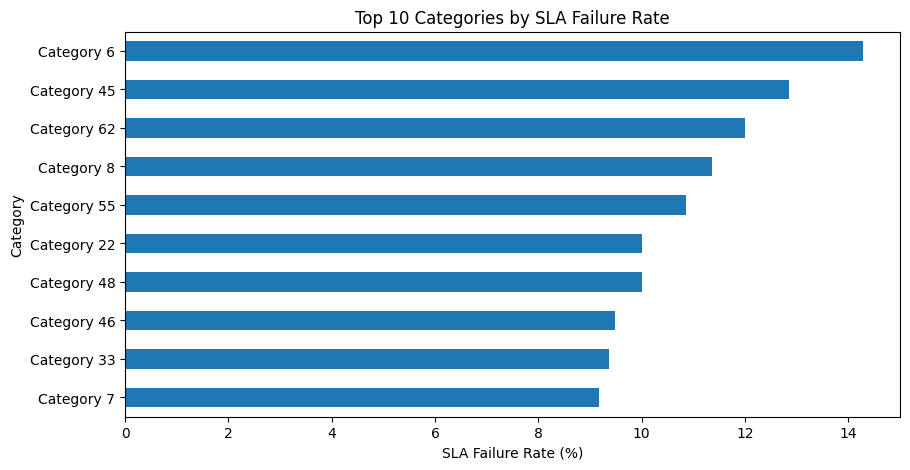

In [13]:
sla_by_cat = (
    df.groupby("category")["made_sla"]
      .apply(lambda x: (~x).mean() * 100)
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10, 5))
sla_by_cat.sort_values().plot(kind="barh")
plt.title("Top 10 Categories by SLA Failure Rate")
plt.xlabel("SLA Failure Rate (%)")
plt.ylabel("Category")
plt.show()

SLA performance is not uniform across categories. A handful of categories exhibit noticeably higher failure rates, suggesting operational bottlenecks and opportunities for focused process optimization.

## 5. Advanced Analysis

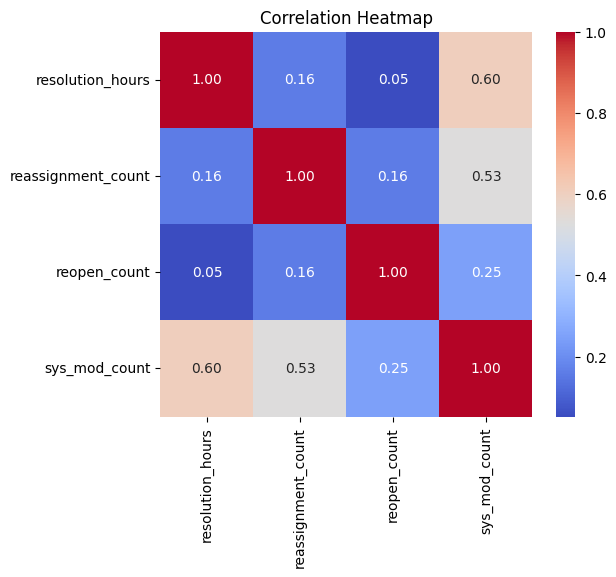

In [14]:
corr = df[
    ["resolution_hours", "reassignment_count", "reopen_count", "sys_mod_count"]
].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

Resolution time shows the strongest positive correlation with sys_mod_count (≈0.60), while reassignment count has only a weak positive relationship with resolution time (≈0.16).

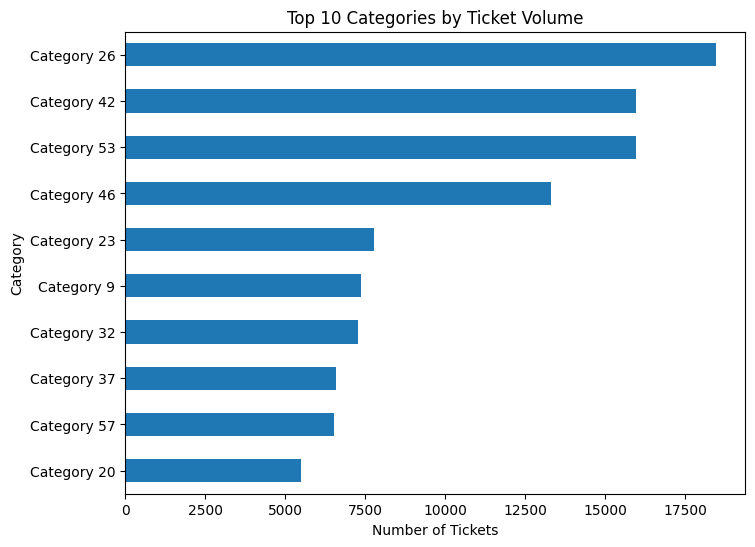

In [15]:
top10 = df["category"].value_counts().head(10)

plt.figure(figsize=(8,6))
top10.sort_values().plot(kind="barh")

plt.title("Top 10 Categories by Ticket Volume")
plt.xlabel("Number of Tickets")
plt.ylabel("Category")

plt.show()

Ticket volume is concentrated in a limited number of categories, with Category 26 generating the highest workload, making it a prime candidate for process optimization.

## 6. Key Findings

- Ticket resolution times are heavily right-skewed, with most tickets resolved quickly while a small proportion take substantially longer.
- Average resolution time tends to increase as reassignment count rises, suggesting repeated handoffs are associated with longer resolution cycles.
- SLA failure rates vary across months, indicating fluctuations in operational performance.
- Certain categories exhibit consistently higher SLA failure rates, highlighting opportunities for targeted process improvements.
- A small number of categories account for a disproportionate share of ticket volume, making them high-impact areas for optimization.
- System modification count has the strongest positive relationship with resolution time among the variables analyzed.